<a href="https://colab.research.google.com/github/Siyun10/public/blob/main/%EC%84%A4%EB%AC%B8%EC%A1%B0%EC%82%AC_20%EA%B0%9C.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
fonts-nanum is already the newest version (20200506-1).
0 upgraded, 0 newly installed, 0 to remove and 2 not upgraded.
/usr/share/fonts: caching, new cache contents: 0 fonts, 1 dirs
/usr/share/fonts/truetype: caching, new cache contents: 0 fonts, 3 dirs
/usr/share/fonts/truetype/humor-sans: caching, new cache contents: 1 fonts, 0 dirs
/usr/share/fonts/truetype/liberation: caching, new cache contents: 16 fonts, 0 dirs
/usr/share/fonts/truetype/nanum: caching, new cache contents: 12 fonts, 0 dirs
/usr/local/share/fonts: caching, new cache contents: 0 fonts, 0 dirs
/root/.local/share/fonts: skipping, no such directory
/root/.fonts: skipping, no such directory
/usr/share/fonts/truetype: skipping, looped directory detected
/usr/share/fonts/truetype/humor-sans: skipping, looped directory detected
/usr/share/fonts/truetype/liberation: skipping, looped directory detected
/usr/share/fonts/truetype/n

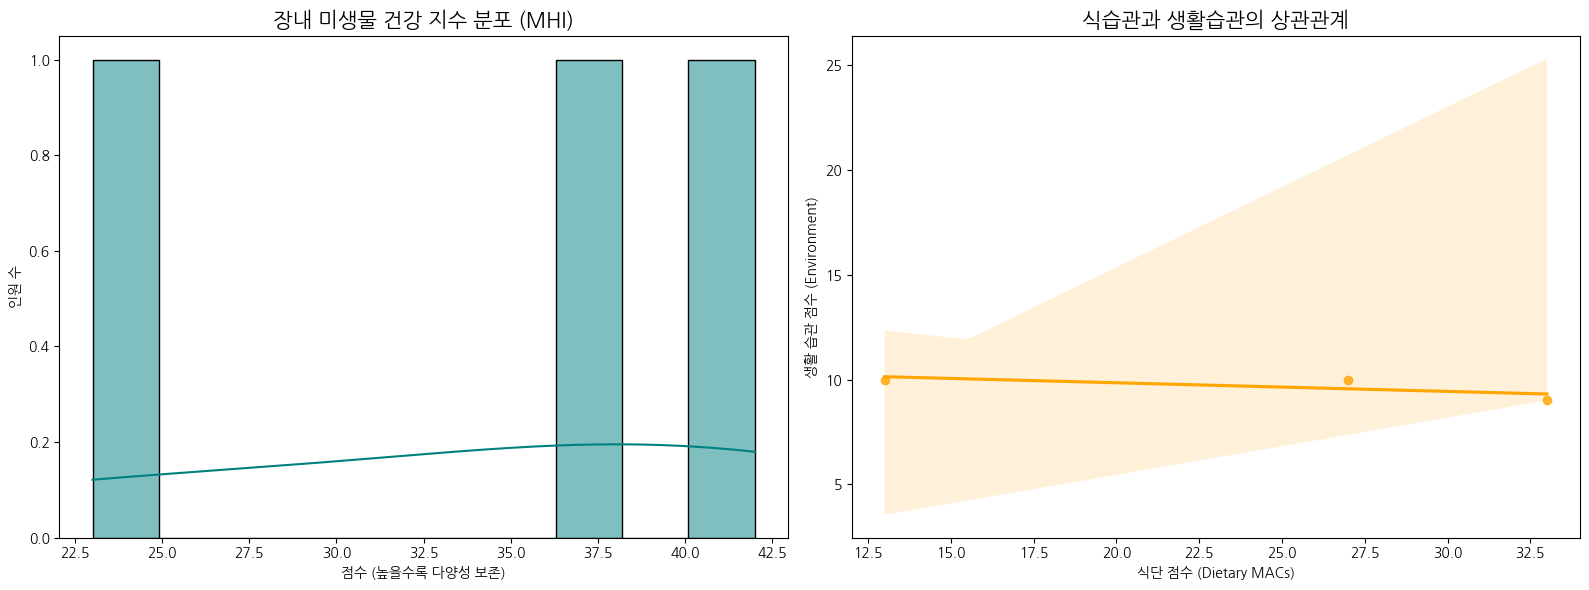

      [ 마이크로바이옴 설문 분석 결과 보고서 ]
▶ 총 참여 인원: 3명
▶ 평균 건강 지수: 34.0 / 65
▶ 우리 집단의 미생물 건강 등급: C (미생물 다양성 위기)
--------------------------------------------------
▶ [가장 우수한 항목]: Fermented
▶ [가장 취약한 항목]: Fruit
--------------------------------------------------
▶ 『10퍼센트 인간』 관점의 조언:
   - 현대적 질병의 위협에 노출되어 있습니다. 가공식품을 줄이고 섬유질(MACs) 섭취를 늘려야 합니다.


In [3]:
# 폰트 설치 및 캐시 초기화
!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm ~/.cache/matplotlib -rf

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. 한글 폰트 설정 (환경에 따라 조정 필요)
plt.rc('font', family='NanumGothic')
plt.rcParams['axes.unicode_minus'] = False

def analyze_microbiome_survey(file_path):
    # 2. 데이터 불러오기
    try:
        df = pd.read_csv(file_path)
    except:
        df = pd.read_csv(file_path, encoding='cp949') # 인코딩 에러 대비

    # 3. 컬럼명 매핑 (설문지의 긴 질문을 짧은 키워드로 변경)
    # 실제 CSV의 열 순서에 맞춰 인덱싱으로 접근합니다.
    col_names = [
        'Timestamp', 'ID', 'Vegetables', 'Grains', 'Fermented', 'Protein', 'Fruit',
        'Processed_Food', 'Sugar', 'Processed_Meat', 'Sweetener', 'Late_Snack',
        'Exercise', 'Sleep', 'Outdoor'
    ]
    # Ensure the DataFrame has the same number of columns as col_names before assigning new names
    if df.shape[1] > len(col_names):
        df = df.iloc[:, :len(col_names)] # Take only the first N columns
    elif df.shape[1] < len(col_names):
        # This case is less likely to cause a ValueError when directly assigning, but handle if needed
        raise ValueError(f"CSV file has fewer columns ({df.shape[1]}) than expected ({len(col_names)}).")

    df.columns = col_names

    # 4. 지수 계산 (Scoring)
    # 긍정 문항 (미생물 친화적): 점수 그대로 합산
    pos_cols = ['Vegetables', 'Grains', 'Fermented', 'Protein', 'Fruit', 'Exercise', 'Sleep', 'Outdoor']
    # 부정 문항 (미생물 위협): 역채점 (6 - 점수)
    neg_cols = ['Processed_Food', 'Sugar', 'Processed_Meat', 'Sweetener', 'Late_Snack']

    df_scored = df.copy()
    for col in neg_cols:
        df_scored[col] = 6 - df[col]

    # 최종 마이크로바이옴 지수 (Max 65점)
    df['Microbiome_Score'] = df_scored[pos_cols + neg_cols].sum(axis=1)

    # 5. 시각화 (Visualization)
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # (1) 건강 지수 분포 히스토그램
    sns.histplot(df['Microbiome_Score'], bins=10, kde=True, color='teal', ax=axes[0])
    axes[0].set_title('장내 미생물 건강 지수 분포 (MHI)', fontsize=15)
    axes[0].set_xlabel('점수 (높을수록 다양성 보존)')
    axes[0].set_ylabel('인원 수')

    # (2) 식단 vs 생활습관 상관관계
    diet_score = df_scored[['Vegetables', 'Grains', 'Fermented', 'Protein', 'Fruit', 'Processed_Food', 'Sugar', 'Processed_Meat', 'Sweetener']].sum(axis=1)
    lifestyle_score = df_scored[['Exercise', 'Sleep', 'Outdoor', 'Late_Snack']].sum(axis=1)

    sns.regplot(x=diet_score, y=lifestyle_score, ax=axes[1], color='orange')
    axes[1].set_title('식습관과 생활습관의 상관관계', fontsize=15)
    axes[1].set_xlabel('식단 점수 (Dietary MACs)')
    axes[1].set_ylabel('생활 습관 점수 (Environment)')

    plt.tight_layout()
    plt.show()

    # 6. 요약 보고서 출력
    avg_score = df['Microbiome_Score'].mean()
    max_score = 65

    print("="*50)
    print("      [ 마이크로바이옴 설문 분석 결과 보고서 ]")
    print("="*50)
    print(f"▶ 총 참여 인원: {len(df)}명")
    print(f"▶ 평균 건강 지수: {avg_score:.1f} / {max_score}")
    print(f"▶ 우리 집단의 미생물 건강 등급: {get_grade(avg_score)}")
    print("-"*50)
    print("▶ [가장 우수한 항목]:", df_scored[pos_cols + neg_cols].mean().idxmax())
    print("▶ [가장 취약한 항목]:", df_scored[pos_cols + neg_cols].mean().idxmin())
    print("-"*50)
    print("▶ 『10퍼센트 인간』 관점의 조언:")
    if avg_score < 40:
        print("   - 현대적 질병의 위협에 노출되어 있습니다. 가공식품을 줄이고 섬유질(MACs) 섭취를 늘려야 합니다.")
    else:
        print("   - 비교적 건강한 미생물 숲을 가꾸고 있습니다. 다양성을 유지하기 위한 노력이 계속 필요합니다.")
    print("="*50)

def get_grade(score):
    if score >= 50: return "A (풍성한 미생물 숲)"
    elif score >= 40: return "B (안정적인 생태계)"
    elif score >= 30: return "C (미생물 다양성 위기)"
    else: return "D (심각한 항생제적 환경)"

# 실행 (파일 경로를 입력하세요)
analyze_microbiome_survey('/content/학생 식습관 및 장내 미생물 분석 설문(응답) - 설문지 응답 시트1.csv')